In [19]:
import torch
import os
import numpy as np
import random

# ── Training Parameters ──────────────────────────────────────────────
CONFIG = {
    # Data
    "data_dir":        "data/processed",
    "img_size":        128,
    "batch_size":      64,
    "split_ratio":     0.7,             # 70% Train / 30% Test (used in prepare_dataset.py)

    # Model
    "num_classes":     4,
    "activation":      "relu",          # Options: relu, leaky_relu, elu
    "dropout":         0.3,

    # Training
    "epochs":          15,
    "learning_rate":   0.001,
    "optimizer":       "adam",           # Options: adam, sgd
    "loss_fn":         "cross_entropy",  # Options: cross_entropy, nll

    # Normalization (ImageNet stats — shared between transforms and visualization)
    "norm_mean":       [0.485, 0.456, 0.406],
    "norm_std":        [0.229, 0.224, 0.225],

    # Reproducibility
    "seed":            1337,
}

# Fix seeds for reproducibility
torch.manual_seed(CONFIG["seed"])
random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

# Device setup for Mac GPU (MPS)
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Config: lr={CONFIG['learning_rate']}, epochs={CONFIG['epochs']}, "
      f"activation={CONFIG['activation']}, loss={CONFIG['loss_fn']}, optimizer={CONFIG['optimizer']}")

Using device: mps
Config: lr=0.001, epochs=15, activation=relu, loss=cross_entropy, optimizer=adam


In [20]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Image Transformations (using CONFIG for normalization and image size)
# Train: stronger augmentation to reduce overfitting on a small dataset
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(CONFIG["norm_mean"], CONFIG["norm_std"])
    ]),
    'test': transforms.Compose([
        transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
        transforms.ToTensor(),
        transforms.Normalize(CONFIG["norm_mean"], CONFIG["norm_std"])
    ]),
}

# 2. Loading datasets from data/processed
image_datasets = {x: datasets.ImageFolder(os.path.join(CONFIG["data_dir"], x), data_transforms[x])
                  for x in ['train', 'test']}

# 3. Creating DataLoaders
dataloaders = {x: DataLoader(image_datasets[x], batch_size=CONFIG["batch_size"],
                             shuffle=(x == 'train'))
              for x in ['train', 'test']}

# 4. Class info
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = image_datasets['train'].classes

print(f"DataLoaders ready.")
print(f"Target classes: {class_names}")
print(f"Train size: {dataset_sizes['train']} | Test size: {dataset_sizes['test']}")

DataLoaders ready.
Target classes: ['Gallery', 'List', 'Login', 'Tutorial']
Train size: 499 | Test size: 214


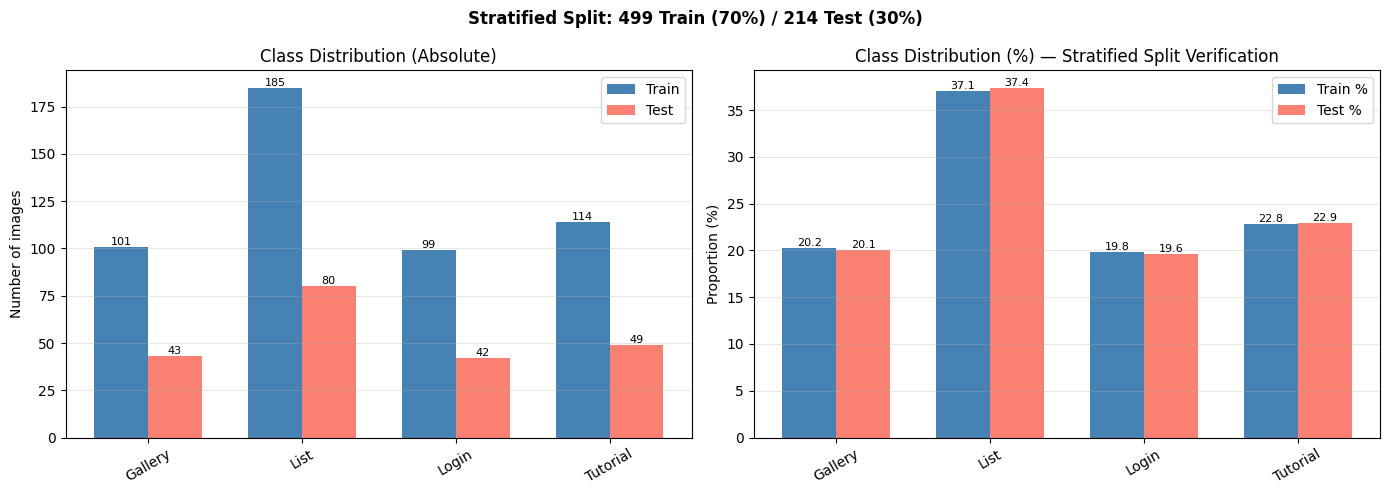


Train/Test ratio per class:
  Gallery   : 101 /  43  (70.1% train)
  List      : 185 /  80  (69.8% train)
  Login     :  99 /  42  (70.2% train)
  Tutorial  : 114 /  49  (69.9% train)


In [21]:
import matplotlib.pyplot as plt

# Count images per class per split
split_counts = {}
for split in ['train', 'test']:
    split_counts[split] = {cls: 0 for cls in class_names}
    for _, label in image_datasets[split].samples:
        split_counts[split][class_names[label]] += 1

# Build a side-by-side bar chart showing the stratified distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Absolute counts
x = range(len(class_names))
width = 0.35
train_counts = [split_counts['train'][c] for c in class_names]
test_counts = [split_counts['test'][c] for c in class_names]

bars1 = ax1.bar([i - width/2 for i in x], train_counts, width, label='Train', color='steelblue')
bars2 = ax1.bar([i + width/2 for i in x], test_counts, width, label='Test', color='salmon')
ax1.set_xticks(x)
ax1.set_xticklabels(class_names, rotation=30)
ax1.set_ylabel('Number of images')
ax1.set_title('Class Distribution (Absolute)')
ax1.legend()
ax1.bar_label(bars1, fontsize=8)
ax1.bar_label(bars2, fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# Right: Proportional (%) — proves the stratified split keeps the same distribution
total_train = sum(train_counts)
total_test = sum(test_counts)
train_pct = [c / total_train * 100 for c in train_counts]
test_pct = [c / total_test * 100 for c in test_counts]

bars3 = ax2.bar([i - width/2 for i in x], train_pct, width, label='Train %', color='steelblue')
bars4 = ax2.bar([i + width/2 for i in x], test_pct, width, label='Test %', color='salmon')
ax2.set_xticks(x)
ax2.set_xticklabels(class_names, rotation=30)
ax2.set_ylabel('Proportion (%)')
ax2.set_title('Class Distribution (%) — Stratified Split Verification')
ax2.legend()
ax2.bar_label(bars3, fmt='%.1f', fontsize=8)
ax2.bar_label(bars4, fmt='%.1f', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle(f'Stratified Split: {total_train} Train ({CONFIG["split_ratio"]*100:.0f}%) / {total_test} Test ({(1-CONFIG["split_ratio"])*100:.0f}%)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
fig.savefig('outputs/figures/class_distribution.png')

print(f"\nTrain/Test ratio per class:")
for c in class_names:
    total = split_counts['train'][c] + split_counts['test'][c]
    ratio = split_counts['train'][c] / total * 100
    print(f"  {c:10s}: {split_counts['train'][c]:3d} / {split_counts['test'][c]:3d}  ({ratio:.1f}% train)")

In [22]:
import torch.nn as nn
import torch.nn.functional as F

class EnricoCNN(nn.Module):
    def __init__(self, num_classes, activation, dropout):
        super(EnricoCNN, self).__init__()

        # Store the activation function (e.g. F.relu, F.leaky_relu, F.elu)
        self.act_fn = getattr(F, activation)

        # Block 1: Basic feature extraction
        # Input: 3 channels (RGB) x 128 x 128
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2)  # Resolution halved each time

        # Block 2: Mid-level features (UI components)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        # After pool -> 32x32

        # Block 3: High-level spatial structures
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        # After pool -> 16x16

        # Fully Connected layers
        # Flattened size: 64 channels * 16px * 16px = 16,384
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.act_fn(self.bn1(self.conv1(x))))
        x = self.pool(self.act_fn(self.bn2(self.conv2(x))))
        x = self.pool(self.act_fn(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)  # Flatten

        x = self.act_fn(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Initialize model from CONFIG and move to device
model = EnricoCNN(
    num_classes=CONFIG["num_classes"],
    activation=CONFIG["activation"],
    dropout=CONFIG["dropout"]
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model ready on {DEVICE}.")
print(f"Total number of trainable parameters: {total_params:,}")

Model ready on mps.
Total number of trainable parameters: 2,121,604


In [23]:
import torch.optim as optim
from tqdm import tqdm
import time

# 1. Setup Loss Function from CONFIG
if CONFIG["loss_fn"] == "cross_entropy":
    criterion = nn.CrossEntropyLoss()
elif CONFIG["loss_fn"] == "nll":
    criterion = nn.NLLLoss()  # Requires log_softmax as last model layer
else:
    raise ValueError(f"Unknown loss function: {CONFIG['loss_fn']}")

# 2. Setup Optimizer from CONFIG
if CONFIG["optimizer"] == "adam":
    optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
elif CONFIG["optimizer"] == "sgd":
    optimizer = optim.SGD(model.parameters(), lr=CONFIG["learning_rate"], momentum=0.9)
else:
    raise ValueError(f"Unknown optimizer: {CONFIG['optimizer']}")

# 3. Training
history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

print(f"Training on {DEVICE} | optimizer={CONFIG['optimizer']} | loss={CONFIG['loss_fn']} | lr={CONFIG['learning_rate']}")
start_time = time.time()

for epoch in range(CONFIG["epochs"]):
    for phase in ['train', 'test']:
        model.train() if phase == 'train' else model.eval()

        running_loss = 0.0
        running_corrects = 0

        pbar = tqdm(dataloaders[phase], desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [{phase}]", leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.float() / dataset_sizes[phase]
        history[f"{phase}_loss"].append(epoch_loss)
        history[f"{phase}_acc"].append(epoch_acc.item())

    print(f"Epoch {epoch+1:2d}/{CONFIG['epochs']} | "
          f"Train Loss: {history['train_loss'][-1]:.4f} Acc: {history['train_acc'][-1]:.4f} | "
          f"Val Loss: {history['test_loss'][-1]:.4f} Acc: {history['test_acc'][-1]:.4f}")

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time // 60:.0f}m {total_time % 60:.0f}s")

Training on mps | optimizer=adam | loss=cross_entropy | lr=0.001


Epoch  1/15 | Train Loss: 4.5420 Acc: 0.3206 | Val Loss: 1.3653 Acc: 0.5047


Epoch  2/15 | Train Loss: 1.5635 Acc: 0.4649 | Val Loss: 1.1752 Acc: 0.5000


Epoch  3/15 | Train Loss: 1.1201 Acc: 0.5010 | Val Loss: 1.0879 Acc: 0.5280


Epoch  4/15 | Train Loss: 0.9953 Acc: 0.5952 | Val Loss: 1.0352 Acc: 0.5561


...

Epoch 11/15 | Train Loss: 0.7588 Acc: 0.6814 | Val Loss: 0.9127 Acc: 0.6075


Epoch 12/15 | Train Loss: 0.7914 Acc: 0.6653 | Val Loss: 0.9469 Acc: 0.6215


Epoch 13/15 | Train Loss: 0.7441 Acc: 0.6513 | Val Loss: 0.9524 Acc: 0.6028


Epoch 14/15 | Train Loss: 0.7369 Acc: 0.7014 | Val Loss: 0.8706 Acc: 0.6682


Epoch 15/15 | Train Loss: 0.7174 Acc: 0.7054 | Val Loss: 0.9071 Acc: 0.6355

Training complete in 0m 52s


Figure saved to outputs/figures/training_curves.png


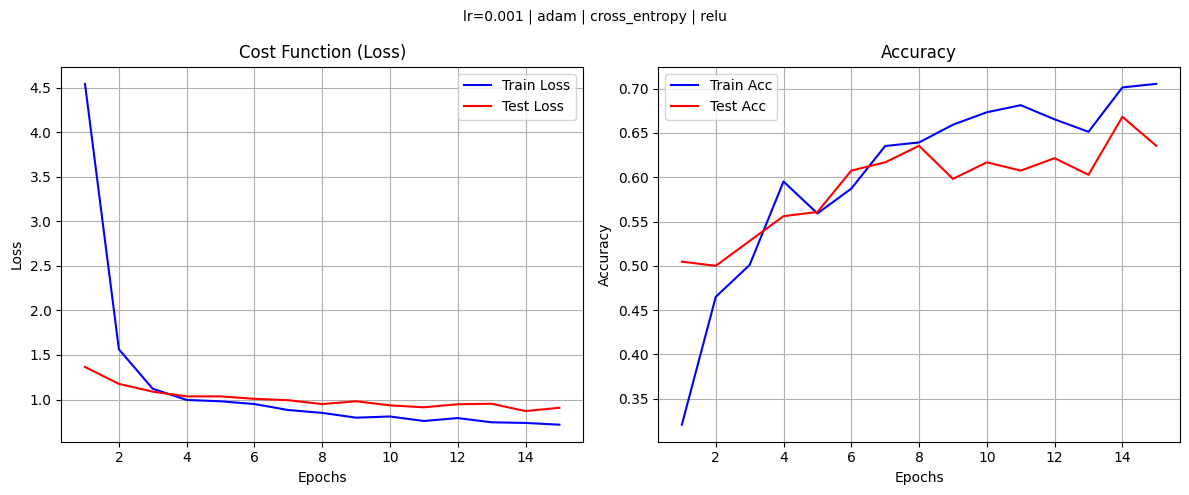

In [24]:
import matplotlib.pyplot as plt

def plot_history(history, save_path="outputs/figures/training_curves.png"):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Loss curves (Cost Function)
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    ax1.plot(epochs, history['test_loss'], 'r-', label='Test Loss')
    ax1.set_title('Cost Function (Loss)')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy curves
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    ax2.plot(epochs, history['test_acc'], 'r-', label='Test Acc')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    fig.suptitle(f"lr={CONFIG['learning_rate']} | {CONFIG['optimizer']} | {CONFIG['loss_fn']} | {CONFIG['activation']}", fontsize=10)
    plt.tight_layout()

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=150)
    print(f"Figure saved to {save_path}")
    plt.show()

plot_history(history)

Figure saved to outputs/figures/confusion_matrix.png


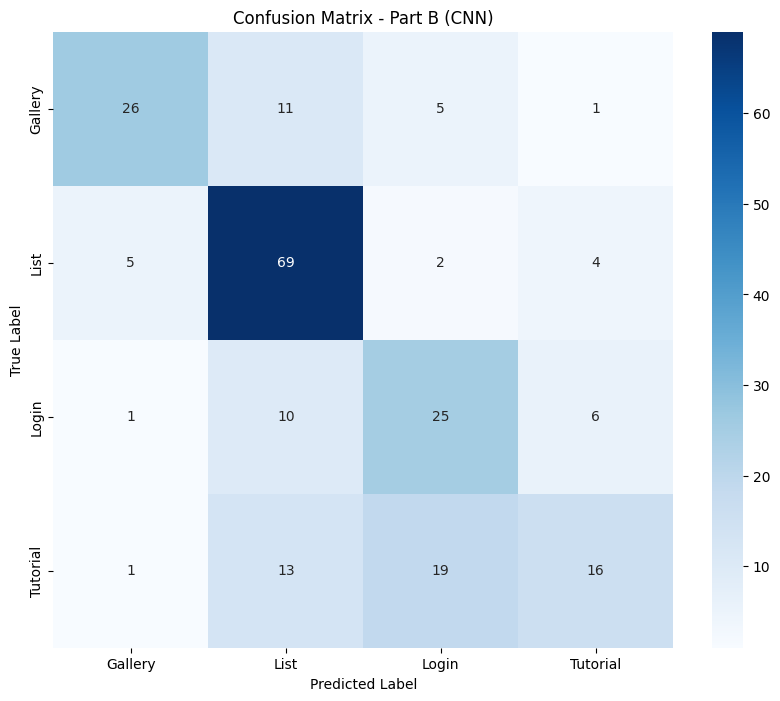


Classification Report:
              precision    recall  f1-score   support

     Gallery       0.79      0.60      0.68        43
        List       0.67      0.86      0.75        80
       Login       0.49      0.60      0.54        42
    Tutorial       0.59      0.33      0.42        49

    accuracy                           0.64       214
   macro avg       0.64      0.60      0.60       214
weighted avg       0.64      0.64      0.62       214



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_confusion_matrix(model, dataloader, class_names, save_path="outputs/figures/confusion_matrix.png"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            outputs = model(inputs.to(DEVICE))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues', ax=ax)
    ax.set_title('Confusion Matrix - Part B (CNN)')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Figure saved to {save_path}")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

plot_confusion_matrix(model, dataloaders['test'], class_names)

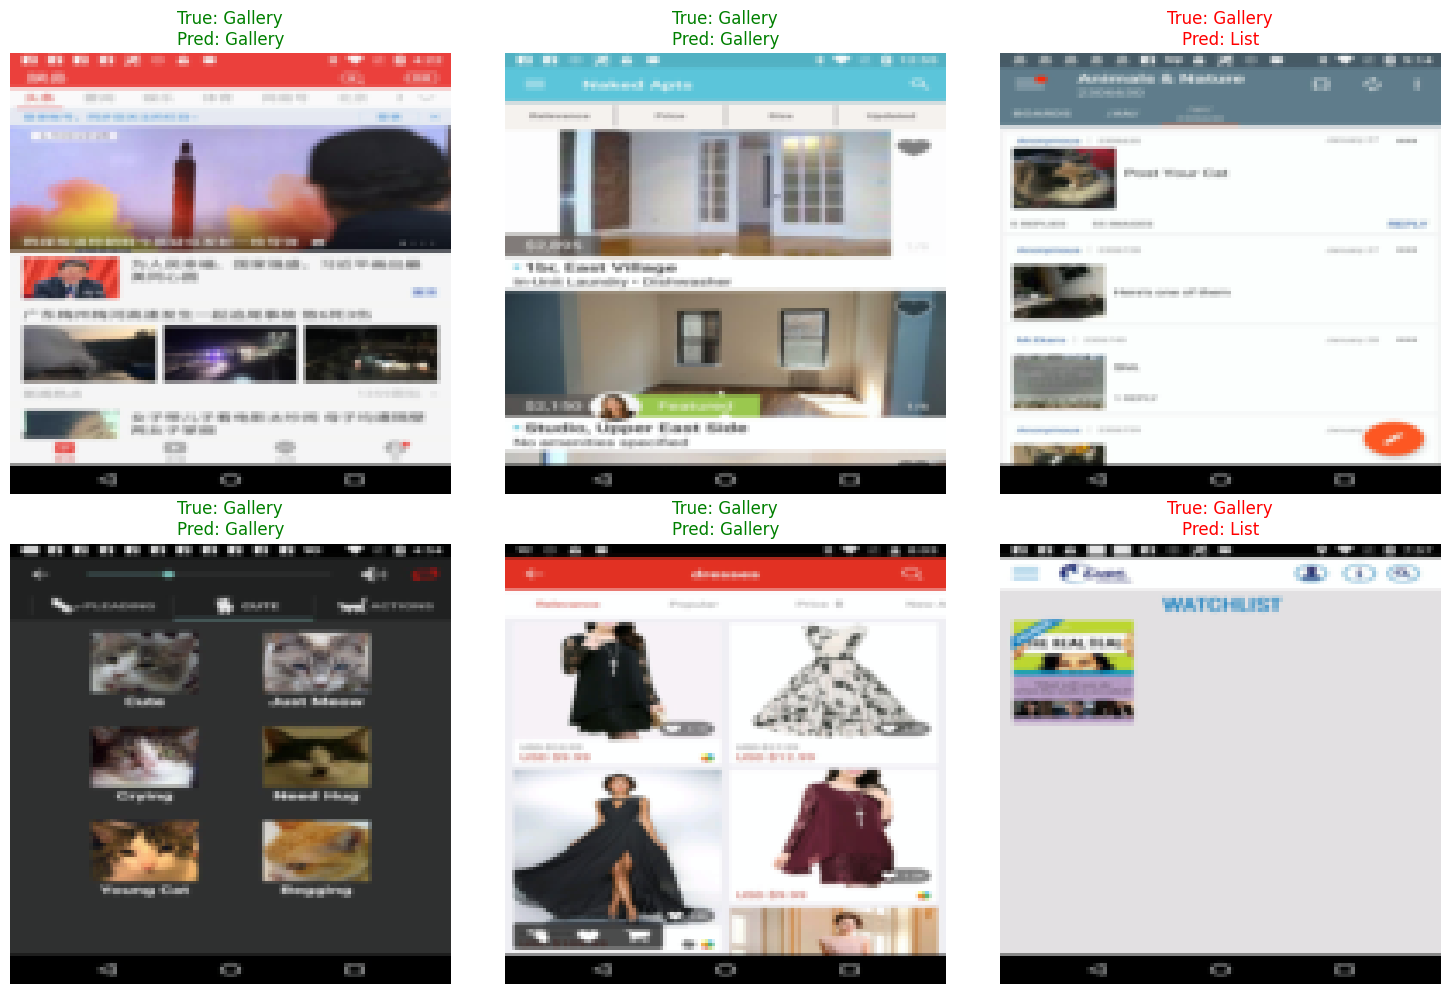

In [26]:
def visualize_predictions(model, dataloader, class_names, num_images=6):
    """Displays sample predictions with true vs predicted labels (green=correct, red=wrong)."""
    model.eval()
    mean = np.array(CONFIG["norm_mean"])
    std = np.array(CONFIG["norm_std"])
    shown = 0

    fig, axes = plt.subplots(2, num_images // 2, figsize=(15, 10))
    axes = axes.flatten()

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size(0)):
                if shown >= num_images:
                    plt.tight_layout()
                    plt.show()
                    return

                ax = axes[shown]
                ax.axis('off')

                # Un-normalize for display
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                img = np.clip(std * img + mean, 0, 1)

                correct = preds[j] == labels[j]
                ax.set_title(f"True: {class_names[labels[j]]}\nPred: {class_names[preds[j]]}",
                             color='green' if correct else 'red')
                ax.imshow(img)
                shown += 1

    plt.tight_layout()
    plt.show()

visualize_predictions(model, dataloaders['test'], class_names)

In [27]:
# Save model checkpoint
save_path = "outputs/checkpoints/enrico_cnn.pth"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': CONFIG,
    'history': history,
    'class_names': class_names,
}, save_path)

print(f"Model saved to {save_path}")

Model saved to outputs/checkpoints/enrico_cnn.pth
